In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope

In [2]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [3]:
def fit_elliptic_envelope(
    df: pd.DataFrame,
    features,
    contamination: float = 0.01,
    support_fraction: float | None = None,
    random_state: int = 42
):
    """
    Ejecuta Elliptic Envelope (Robust Covariance) y devuelve:
    - df_result con anomaly_ee y ee_score
    - modelo entrenado
    """

    df_model = df.copy()

    X = (
        df_model[features]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    idx = X.index

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = EllipticEnvelope(
        contamination=contamination,
        support_fraction=support_fraction,   # None = automático
        random_state=random_state
    )
    model.fit(X_scaled)

    pred = model.predict(X_scaled)  # 1 normal, -1 outlier
    # decision_function: más pequeño (más negativo) = más outlier
    # lo convertimos a score positivo: más alto = más anómalo
    ee_score = -model.decision_function(X_scaled)

    df_model["anomaly_ee"] = np.nan
    df_model["ee_score"] = np.nan

    df_model.loc[idx, "anomaly_ee"] = (pred == -1)
    df_model.loc[idx, "ee_score"] = ee_score

    return df_model, model

In [4]:
def compute_ee_metrics(df: pd.DataFrame):

    df_eval = df.dropna(subset=["anomaly_ee"])

    total = len(df_eval)
    anomalies = df_eval["anomaly_ee"].sum()
    rate = anomalies / total if total else 0

    metrics = {
        "total_points": total,
        "total_anomalies": int(anomalies),
        "anomaly_rate": rate,
        "score_mean": df_eval["ee_score"].mean(),
        "score_std": df_eval["ee_score"].std(),
        "score_p95": df_eval["ee_score"].quantile(0.95),
        "score_p99": df_eval["ee_score"].quantile(0.99),
        "score_max": df_eval["ee_score"].max()
    }

    # Comparación con baseline si existe
    if "anomaly_simple" in df.columns:
        overlap = (
            (df_eval["anomaly_ee"].astype(bool)) &
            (df_eval["anomaly_simple"].astype(bool))
        ).sum()
        metrics["baseline_overlap"] = int(overlap)

    return metrics

In [5]:
def plot_ee_results(df, time_col="open_time", price_col="close"):

    df_plot = df.dropna(subset=["anomaly_ee"])

    # Precio + anomalías
    plt.figure()
    plt.plot(df_plot[time_col], df_plot[price_col])
    anomalies = df_plot[df_plot["anomaly_ee"] == True]
    plt.scatter(anomalies[time_col], anomalies[price_col])
    plt.title("Precio con anomalías detectadas por Elliptic Envelope")
    plt.show()

    # Score en el tiempo
    plt.figure()
    plt.plot(df_plot[time_col], df_plot["ee_score"])
    plt.title("Elliptic Envelope Score en el tiempo")
    plt.show()

    # Histograma score
    plt.figure()
    plt.hist(df_plot["ee_score"].dropna(), bins=50)
    plt.title("Distribución del Elliptic Envelope Score")
    plt.show()

In [6]:
def plot_ee_pca_score(df, features, score_col="ee_score", title="EE PCA score", cmap="RdYlGn_r"):

    d = df.dropna(subset=features + [score_col]).copy()
    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    X_scaled = StandardScaler().fit_transform(X.values)

    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X_scaled)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [7]:
def plot_elliptic_envelope_ellipse(
    df,
    features,
    contamination: float = 0.01,
    sample_n: int | None = 30000,
    random_state: int = 42,
    title: str = "Elliptic Envelope en PCA (2D) con elipse",
):
    """
    1) Toma features -> estandariza
    2) PCA a 2D
    3) Ajusta EllipticEnvelope en 2D
    4) Grafica puntos normales vs outliers y la elipse (contorno)
    """

    # --- preparar datos ---
    d = df[features].replace([np.inf, -np.inf], np.nan).dropna().copy()

    # sample para que no explote con 281k puntos
    if sample_n is not None and len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d.values
    Xs = StandardScaler().fit_transform(X)

    # --- PCA 2D ---
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    # --- Elliptic Envelope en 2D ---
    ee2d = EllipticEnvelope(contamination=contamination, random_state=random_state)
    ee2d.fit(X2)

    pred = ee2d.predict(X2)  # 1 normal, -1 outlier
    normal = pred == 1
    outlier = pred == -1

    # --- malla para contorno (elipse) ---
    x_min, x_max = X2[:, 0].min(), X2[:, 0].max()
    y_min, y_max = X2[:, 1].min(), X2[:, 1].max()

    pad_x = 0.10 * (x_max - x_min)
    pad_y = 0.10 * (y_max - y_min)

    xx, yy = np.meshgrid(
        np.linspace(x_min - pad_x, x_max + pad_x, 300),
        np.linspace(y_min - pad_y, y_max + pad_y, 300)
    )

    Z = ee2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # --- plot ---
    plt.figure()
    plt.scatter(X2[normal, 0], X2[normal, 1], label="Normal")
    plt.scatter(X2[outlier, 0], X2[outlier, 1], label="Outlier")

    # Contorno donde decision_function = 0 (frontera)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

    return ee2d

In [8]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [9]:
df_ee, model_ee = fit_elliptic_envelope(
    df=df,
    features=features,
    contamination=0.01
)

C:\Users\cecil\AppData\Local\Temp\ipykernel_15552\3082461935.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_model.loc[idx, "anomaly_ee"] = (pred == -1)


In [10]:
metrics_ee = compute_ee_metrics(df_ee)
print(metrics_ee)

{'total_points': 281097, 'total_anomalies': 2811, 'anomaly_rate': 0.010000106724724917, 'score_mean': -447.5357365604408, 'score_std': 156.33733320468255, 'score_p95': -292.10615884888995, 'score_p99': -2.5374868222252656e-13, 'score_max': 33435.30035855662, 'baseline_overlap': 782}


In [ ]:
plot_ee_results(df_ee)

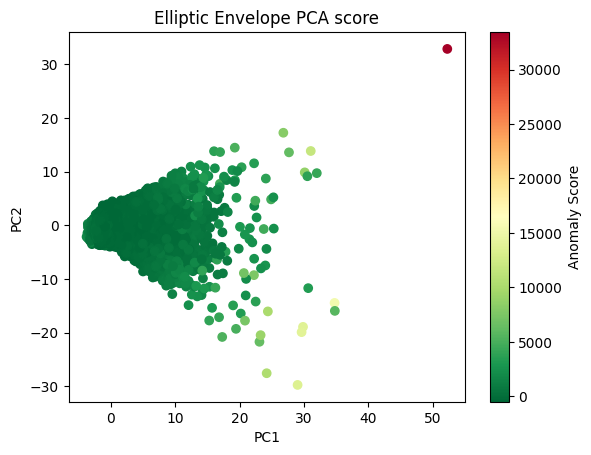

In [11]:
plot_ee_pca_score(df_ee, features, title="Elliptic Envelope PCA score")

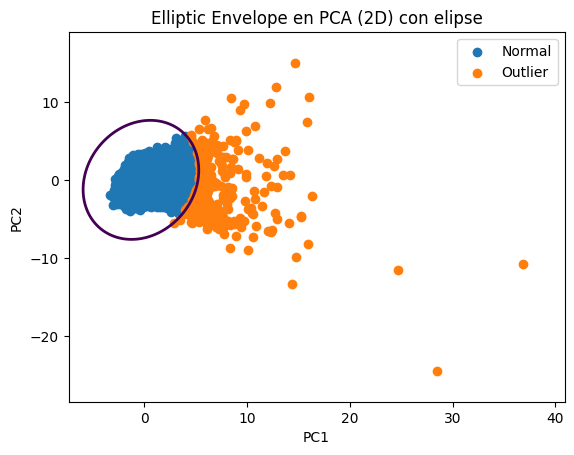

,store_precision,True
,assume_centered,False
,support_fraction,None
,contamination,0.01
,random_state,42


In [12]:
plot_elliptic_envelope_ellipse(
    df,
    features,
    contamination=0.01,
    sample_n=30000
)